# fMRI Sleep Connectivity Analysis

This project explores how brain regions interact over time during sleep, using functional connectivity and dynamic state analysis.

In [2]:
import sys
print(sys.executable)

C:\Users\hp\anaconda3\python.exe


In [3]:
!{sys.executable} -m pip install nilearn

  Using cached nilearn-0.13.1-py3-none-any.whl.metadata (12 kB)
Using cached nilearn-0.13.1-py3-none-any.whl (10.6 MB)


In [2]:
import sys
import nibabel as nib
from nilearn import datasets
from nilearn.input_data import NiftiLabelsMasker
import numpy as np
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Nibabel version:", nib.__version__)

C:\Users\hp\AppData\Local\Temp\ipykernel_92060\2469839972.py:4: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


Python executable: C:\Users\hp\anaconda3\python.exe
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Nibabel version: 5.4.2


In [3]:
fmri_path = "sub-00002_ses-1_task-sleep_acq-20160531T2257_bold.nii"

In [4]:
import os

print(fmri_path)
print(os.path.exists(fmri_path))

sub-00002_ses-1_task-sleep_acq-20160531T2257_bold.nii
True


In [5]:
img = nib.load(fmri_path)
data = img.get_fdata() # converts it into numerical data
print(data.shape)

(96, 72, 50, 505)


##  Visualize Brain Slice

This helps confirm that the scan looks correct.

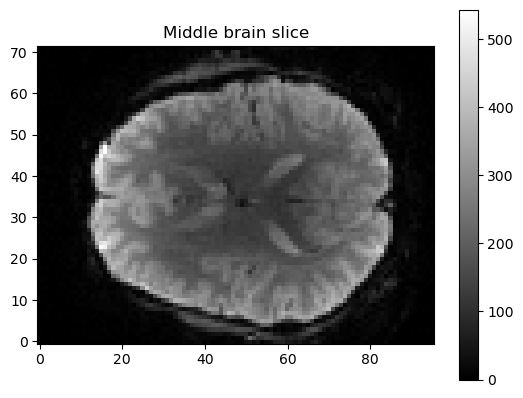

In [7]:
import matplotlib.pyplot as plt

# take one timepoint
t = 0

# take one slice from the middle
slice_img = data[:, :, data.shape[2]//2, t]

plt.imshow(slice_img.T, cmap="gray", origin="lower")
plt.title("Middle brain slice")
plt.colorbar()
plt.show()

##  Check One Voxel Over Time

This shows how a single point in the brain changes across time.

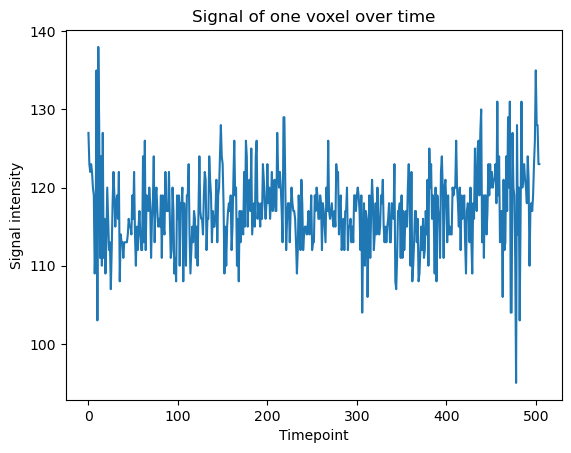

In [8]:
x, y, z = 48, 36, 25  # roughly near the center

voxel_signal = data[x, y, z, :]

plt.plot(voxel_signal)
plt.title("Signal of one voxel over time")
plt.xlabel("Timepoint")
plt.ylabel("Signal intensity")
plt.show()

## Step 5: Extract Brain Region Signals

Instead of analyzing individual voxels, I group them into meaningful brain regions using an atlas.

In [9]:
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\hp\nilearn_data\fsl

In [10]:
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True) # This creates th tool that extracts the brain area signals

time_series = masker.fit_transform(img) # take my brain scan, use the brain map, and extract one activity line for each named brain area

print(time_series.shape)

C:\Users\hp\AppData\Local\Temp\ipykernel_92060\600319715.py:3: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(img) # take my brain scan, use the brain map, and extract one activity line for each named brain area


(505, 48)


#### This shows the brainregions associated

In [13]:
labels = atlas.labels
print("Total labels:", len(labels))
print(labels[:10])

Total labels: 49
['Background', 'Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division']


In [14]:
region_labels = labels[1:]
print("Usable region names:", len(region_labels))
print(region_labels[:10])

Usable region names: 48
['Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division', 'Superior Temporal Gyrus, posterior division']


## Compute Functional Connectivity

This measures how similarly different brain regions behave over time.
#### This flips the brain regions and compares them with each other to see if theres any relationship existing

(48, 48)


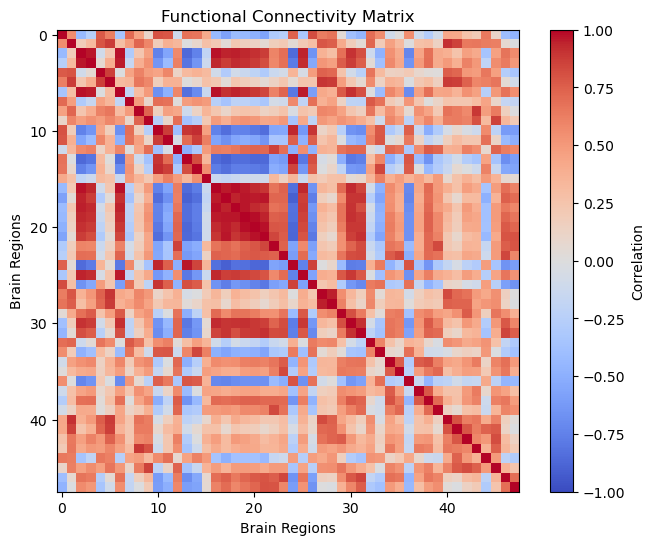

In [15]:

corr_matrix = np.corrcoef(time_series.T)
print(corr_matrix.shape)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Functional Connectivity Matrix")
plt.xlabel("Brain Regions")
plt.ylabel("Brain Regions")
plt.show()

### This shows us the names where the relationship are stronger

In [16]:
corr_copy = corr_matrix.copy()
np.fill_diagonal(corr_copy, 0)

pairs = []
n = len(region_labels)

for i in range(n):
    for j in range(i + 1, n):
        pairs.append((corr_copy[i, j], region_labels[i], region_labels[j]))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

for corr, r1, r2 in pairs_sorted[:10]:
    print(f"{r1} ↔ {r2} = {corr:.2f}")

Supramarginal Gyrus, posterior division ↔ Angular Gyrus = 0.98
Postcentral Gyrus ↔ Supramarginal Gyrus, anterior division = 0.98
Precentral Gyrus ↔ Postcentral Gyrus = 0.98
Angular Gyrus ↔ Lateral Occipital Cortex, superior division = 0.98
Superior Frontal Gyrus ↔ Precentral Gyrus = 0.97
Superior Frontal Gyrus ↔ Postcentral Gyrus = 0.97
Supramarginal Gyrus, anterior division ↔ Supramarginal Gyrus, posterior division = 0.97
Superior Frontal Gyrus ↔ Middle Frontal Gyrus = 0.96
Superior Parietal Lobule ↔ Lateral Occipital Cortex, superior division = 0.96
Inferior Temporal Gyrus, anterior division ↔ Frontal Medial Cortex = 0.96


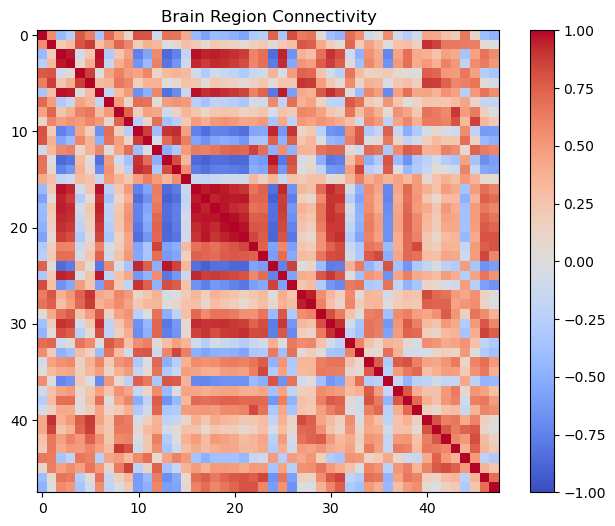

In [17]:
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("Brain Region Connectivity")
plt.show()

## Focus on Sleep-Relevant Regions

I select specific brain regions that are important for sleep analysis to reduce noise.

In [22]:
for i, name in enumerate(region_labels):
    print(i, name)

0 Frontal Pole
1 Insular Cortex
2 Superior Frontal Gyrus
3 Middle Frontal Gyrus
4 Inferior Frontal Gyrus, pars triangularis
5 Inferior Frontal Gyrus, pars opercularis
6 Precentral Gyrus
7 Temporal Pole
8 Superior Temporal Gyrus, anterior division
9 Superior Temporal Gyrus, posterior division
10 Middle Temporal Gyrus, anterior division
11 Middle Temporal Gyrus, posterior division
12 Middle Temporal Gyrus, temporooccipital part
13 Inferior Temporal Gyrus, anterior division
14 Inferior Temporal Gyrus, posterior division
15 Inferior Temporal Gyrus, temporooccipital part
16 Postcentral Gyrus
17 Superior Parietal Lobule
18 Supramarginal Gyrus, anterior division
19 Supramarginal Gyrus, posterior division
20 Angular Gyrus
21 Lateral Occipital Cortex, superior division
22 Lateral Occipital Cortex, inferior division
23 Intracalcarine Cortex
24 Frontal Medial Cortex
25 Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
26 Subcallosal Cortex
27 Paracingulate Gyrus
28 Cingulate Gyr

#### These are the region that are involved in sleep and wakefulness

In [23]:
sleep_regions = [
    "Frontal Pole",
    "Superior Frontal Gyrus",
    "Middle Frontal Gyrus",
    "Frontal Medial Cortex",
    "Frontal Orbital Cortex",

    "Cingulate Gyrus, anterior division",
    "Cingulate Gyrus, posterior division",
    "Precuneous Cortex",

    "Angular Gyrus",
    "Supramarginal Gyrus, anterior division",
    "Supramarginal Gyrus, posterior division",
    "Superior Parietal Lobule",

    "Temporal Pole",
    "Middle Temporal Gyrus, anterior division",
    "Middle Temporal Gyrus, posterior division",

    "Parahippocampal Gyrus, anterior division",
    "Parahippocampal Gyrus, posterior division",

    "Lateral Occipital Cortex, superior division",
    "Lateral Occipital Cortex, inferior division",
    "Cuneal Cortex",
    "Occipital Pole"
]

#### Matches the with the corresponding regions in the data

In [24]:
selected_indices = [i for i, name in enumerate(region_labels) if name in sleep_regions]
selected_labels = [region_labels[i] for i in selected_indices]

print("Number of selected regions:", len(selected_labels))
print(selected_labels)

Number of selected regions: 21
['Frontal Pole', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Temporal Pole', 'Middle Temporal Gyrus, anterior division', 'Middle Temporal Gyrus, posterior division', 'Superior Parietal Lobule', 'Supramarginal Gyrus, anterior division', 'Supramarginal Gyrus, posterior division', 'Angular Gyrus', 'Lateral Occipital Cortex, superior division', 'Lateral Occipital Cortex, inferior division', 'Frontal Medial Cortex', 'Cingulate Gyrus, anterior division', 'Cingulate Gyrus, posterior division', 'Precuneous Cortex', 'Cuneal Cortex', 'Frontal Orbital Cortex', 'Parahippocampal Gyrus, anterior division', 'Parahippocampal Gyrus, posterior division', 'Occipital Pole']


#### Extracts only those regions

In [25]:
sleep_time_series = time_series[:, selected_indices]

print(sleep_time_series.shape)

(505, 21)


#### builds connectivity for those regions

In [26]:
sleep_corr = np.corrcoef(sleep_time_series.T)

print(sleep_corr.shape)

(21, 21)


####  Shows us which parts have the strongest connection


In [27]:
corr_copy = sleep_corr.copy()
np.fill_diagonal(corr_copy, 0)

pairs = []
n = len(selected_labels)

for i in range(n):
    for j in range(i + 1, n):
        pairs.append((corr_copy[i, j], selected_labels[i], selected_labels[j]))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

for corr, r1, r2 in pairs_sorted[:10]:
    print(f"{r1} ↔ {r2} = {corr:.2f}")

Supramarginal Gyrus, posterior division ↔ Angular Gyrus = 0.98
Angular Gyrus ↔ Lateral Occipital Cortex, superior division = 0.98
Supramarginal Gyrus, anterior division ↔ Supramarginal Gyrus, posterior division = 0.97
Superior Frontal Gyrus ↔ Middle Frontal Gyrus = 0.96
Superior Parietal Lobule ↔ Lateral Occipital Cortex, superior division = 0.96
Superior Parietal Lobule ↔ Supramarginal Gyrus, posterior division = 0.96
Superior Parietal Lobule ↔ Angular Gyrus = 0.96
Superior Frontal Gyrus ↔ Supramarginal Gyrus, anterior division = 0.95
Supramarginal Gyrus, posterior division ↔ Lateral Occipital Cortex, superior division = 0.94
Superior Frontal Gyrus ↔ Superior Parietal Lobule = 0.94


##  Dynamic Connectivity

Instead of looking at one average pattern, I split the data into smaller time windows to see how connectivity changes over time.

In [28]:
window_size = 50   # number of time points per window
step_size = 10     # how much we move each time

windows = []

for start in range(0, sleep_time_series.shape[0] - window_size, step_size):
    end = start + window_size
    windows.append(sleep_time_series[start:end])

print("Number of windows:", len(windows))

Number of windows: 46


### Compute connectivity for each window

In [29]:
dynamic_matrices = []

for w in windows:
    corr = np.corrcoef(w.T)
    dynamic_matrices.append(corr)

print("Number of connectivity matrices:", len(dynamic_matrices))

Number of connectivity matrices: 46


In [30]:
flattened = []

for mat in dynamic_matrices:
    flattened.append(mat.flatten())

flattened = np.array(flattened)

print(flattened.shape)

(46, 441)


##  Identify Connectivity States

I group similar connectivity patterns together. Each group is called a "state".

A state represents a repeating pattern of how brain regions are connected.

In [31]:
from sklearn.cluster import KMeans

k = 3  # number of states (we start simple)

kmeans = KMeans(n_clusters=k, random_state=0)
states = kmeans.fit_predict(flattened)

print(states[:20])

C:\Users\hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\hp\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\hp\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

[1 1 2 0 0 0 0 0 0 2 2 2 2 2 2 0 2 2 2 2]


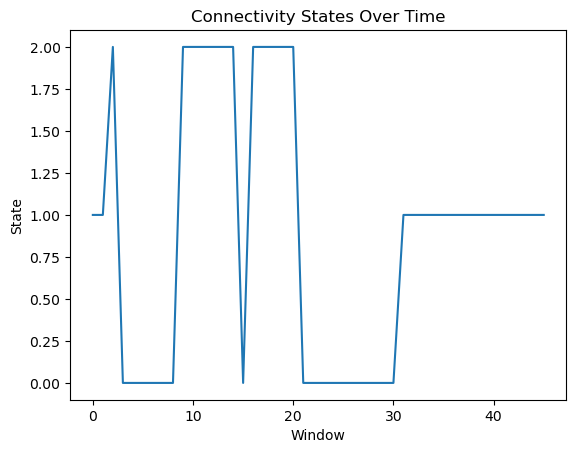

In [32]:
plt.plot(states)
plt.title("Connectivity States Over Time")
plt.xlabel("Window")
plt.ylabel("State")
plt.show()

In [33]:
state_matrices = []

for i in range(k):
    # get all matrices belonging to this state
    mats = [dynamic_matrices[j] for j in range(len(states)) if states[j] == i]
    
    # average them
    avg_mat = np.mean(mats, axis=0)
    
    state_matrices.append(avg_mat)

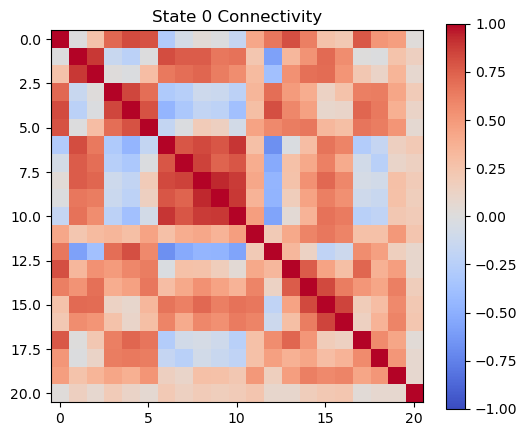

In [34]:
plt.figure(figsize=(6,5))
plt.imshow(state_matrices[0], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.title("State 0 Connectivity")
plt.show()

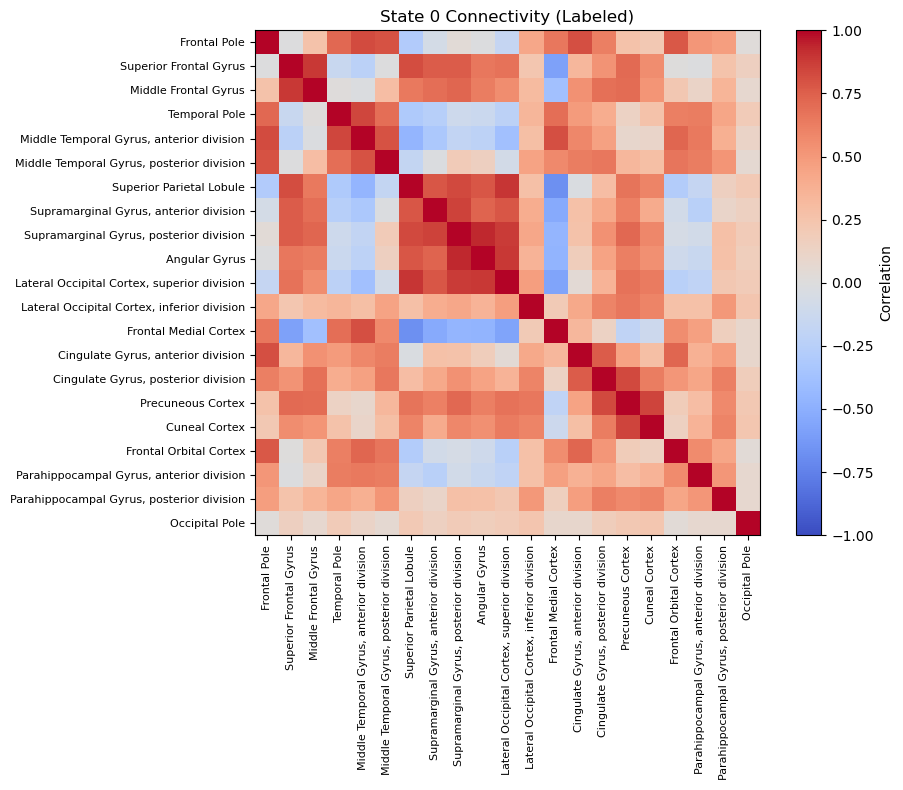

In [35]:
plt.figure(figsize=(10, 8))

plt.imshow(state_matrices[0], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(np.arange(len(selected_labels)), selected_labels, rotation=90, fontsize=8)
plt.yticks(np.arange(len(selected_labels)), selected_labels, fontsize=8)

plt.title("State 0 Connectivity (Labeled)")
plt.tight_layout()
plt.show()

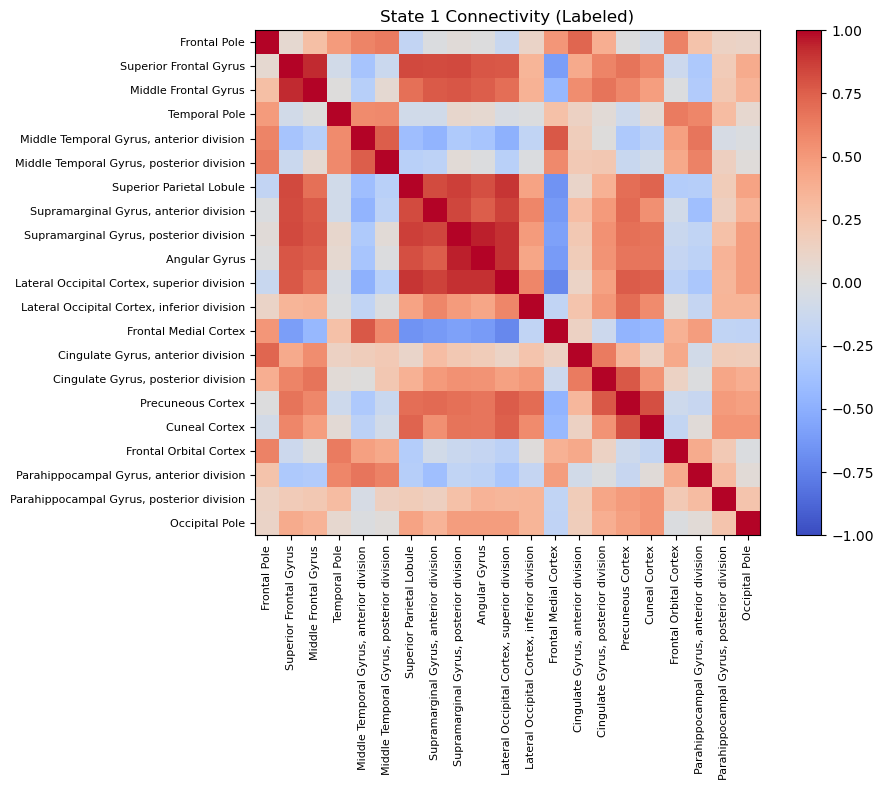

In [36]:
# State 1
plt.figure(figsize=(10, 8))
plt.imshow(state_matrices[1], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(np.arange(len(selected_labels)), selected_labels, rotation=90, fontsize=8)
plt.yticks(np.arange(len(selected_labels)), selected_labels, fontsize=8)
plt.title("State 1 Connectivity (Labeled)")
plt.tight_layout()
plt.show()


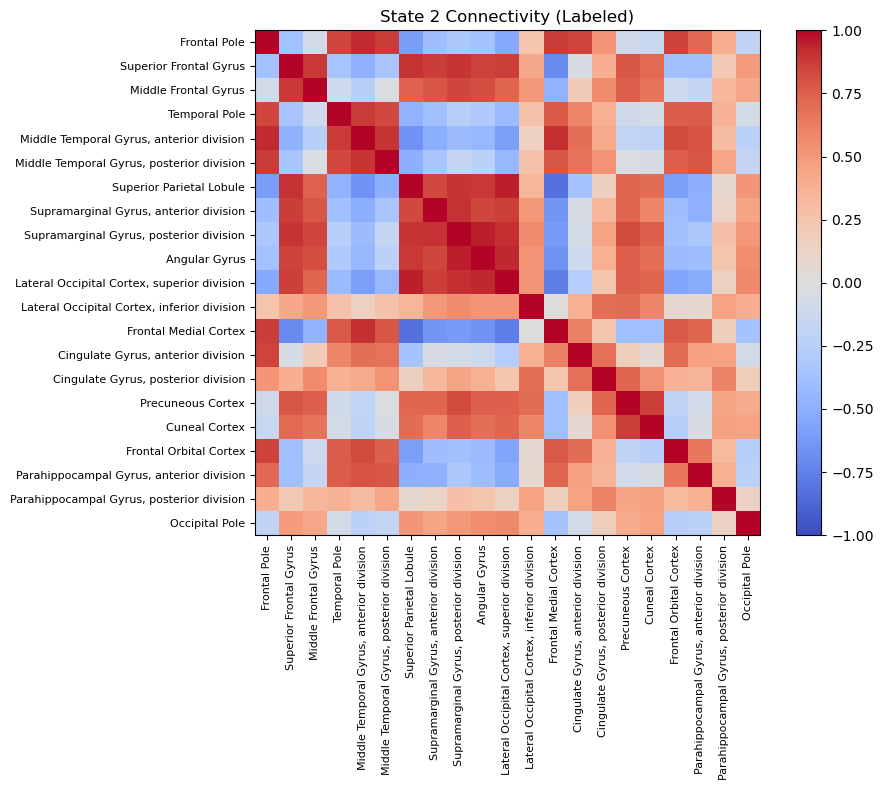

In [37]:
# State 2
plt.figure(figsize=(10, 8))
plt.imshow(state_matrices[2], cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(np.arange(len(selected_labels)), selected_labels, rotation=90, fontsize=8)
plt.yticks(np.arange(len(selected_labels)), selected_labels, fontsize=8)
plt.title("State 2 Connectivity (Labeled)")
plt.tight_layout()
plt.show()

In [38]:
def print_top_connections(matrix, labels, top_n=5):
    mat = matrix.copy()
    np.fill_diagonal(mat, 0)

    pairs = []
    n = len(labels)

    for i in range(n):
        for j in range(i + 1, n):
            pairs.append((mat[i, j], labels[i], labels[j]))

    pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

    for corr, r1, r2 in pairs_sorted[:top_n]:
        print(f"{r1} ↔ {r2} = {corr:.2f}")

In [39]:
print("State 0")
print_top_connections(state_matrices[0], selected_labels)

print("\nState 1")
print_top_connections(state_matrices[1], selected_labels)

print("\nState 2")
print_top_connections(state_matrices[2], selected_labels)

State 0
Supramarginal Gyrus, posterior division ↔ Angular Gyrus = 0.93
Superior Parietal Lobule ↔ Lateral Occipital Cortex, superior division = 0.90
Superior Frontal Gyrus ↔ Middle Frontal Gyrus = 0.89
Angular Gyrus ↔ Lateral Occipital Cortex, superior division = 0.89
Supramarginal Gyrus, posterior division ↔ Lateral Occipital Cortex, superior division = 0.88

State 1
Supramarginal Gyrus, posterior division ↔ Angular Gyrus = 0.95
Superior Frontal Gyrus ↔ Middle Frontal Gyrus = 0.92
Angular Gyrus ↔ Lateral Occipital Cortex, superior division = 0.91
Supramarginal Gyrus, posterior division ↔ Lateral Occipital Cortex, superior division = 0.91
Superior Parietal Lobule ↔ Lateral Occipital Cortex, superior division = 0.89

State 2
Supramarginal Gyrus, posterior division ↔ Angular Gyrus = 0.95
Superior Parietal Lobule ↔ Lateral Occipital Cortex, superior division = 0.95
Angular Gyrus ↔ Lateral Occipital Cortex, superior division = 0.93
Frontal Pole ↔ Middle Temporal Gyrus, anterior division = 

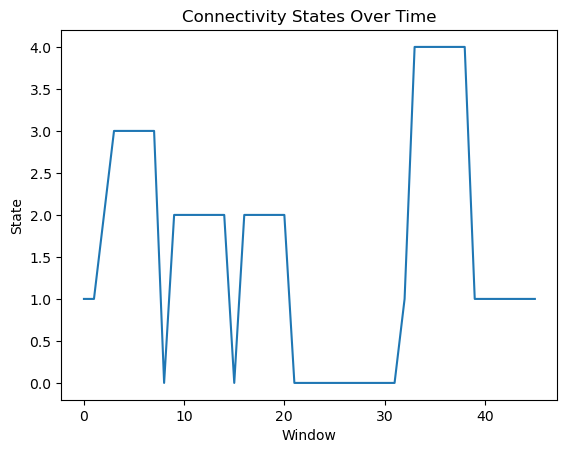

In [41]:
plt.plot(states)
plt.title("Connectivity States Over Time")
plt.xlabel("Window")
plt.ylabel("State")
plt.show()

## Interpretation of States

I found that:

- Parietal and occipital regions form a stable core network
- Frontal and temporal regions vary across states

This suggests the brain switches between different modes during sleep.